# Proyecto Final de Data Science — Oil & Gas
## Notebook 01 — 2ª pre-entrega: Validación y análisis exploratorio inicial

**Tema del proyecto:** análisis y futura predicción del desempeño productivo de pozos gasíferos shale de Vaca Muerta.  
**Dataset:** Producción de Pozos de Gas y Petróleo No Convencional — Secretaría de Energía de la Nación.  
**Fuente:** [Datos Argentina — Producción de petróleo y gas por pozo (Capítulo IV)](https://www.datos.gob.ar/dataset/produccion-de-petroleo-y-gas-por-pozo)

### Objetivo de esta 2ª pre-entrega
Explorar y transformar el dataset con **Pandas** para comprender su estructura, granularidad, cobertura temporal y geográfica, calidad de datos y comportamiento productivo. A partir del EDA se busca justificar un universo de análisis más homogéneo y manejable para las próximas etapas del proyecto.

El alcance preliminar definido al cierre del EDA es: **Cuenca Neuquina → pozos gasíferos → shale → formación Vaca Muerta**. Para las etapas posteriores se propone estudiar si la información de los primeros seis meses de producción permite anticipar el desempeño gasífero futuro del pozo, tomando como target candidato la producción acumulada entre los meses 7 y 12.

> En esta pre-entrega todavía no se entrenan modelos predictivos. El foco es el **Análisis Exploratorio de Datos (AED)**, las transformaciones con Pandas, la visualización y la toma de decisiones fundamentadas sobre el universo de estudio.


## 0. Configuración del entorno y carga manual del dataset

### ¿Qué queremos hacer?
Para evitar dependencias de Google Drive, rutas personales o APIs externas, el dataset se cargará **manualmente desde la computadora al entorno temporal de Google Colab**.

Al ejecutar la siguiente celda, Colab mostrará el botón **“Elegir archivos”**. Debe seleccionarse el CSV descargado. El archivo permanecerá disponible durante la sesión actual; si el runtime se reinicia, será necesario volver a cargarlo.


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Carga manual del CSV al entorno temporal de Colab.
print("Seleccioná el CSV 'Producción de Pozos de Gas y Petróleo No Convencional'.")
uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No se cargó ningún archivo.")

if len(uploaded) > 1:
    raise RuntimeError("Seleccioná un único archivo CSV.")

archivo_csv = next(iter(uploaded))

if not archivo_csv.lower().endswith(".csv"):
    raise ValueError(f"El archivo seleccionado no es un CSV: {archivo_csv}")

# files.upload() guarda el archivo en el directorio de trabajo de Colab (/content).
DATA_PATH = Path("/content") / archivo_csv

# Liberamos del diccionario la copia del archivo en memoria.
del uploaded

print(f"Archivo cargado: {DATA_PATH.name}")
print(f"Ubicación temporal: {DATA_PATH}")
print(f"Tamaño: {DATA_PATH.stat().st_size / 1024**2:.1f} MiB")


Seleccioná el CSV 'Producción de Pozos de Gas y Petróleo No Convencional'.


Saving produccin-de-pozos-de-gas-y-petrleo-no-convencional (1).csv to produccin-de-pozos-de-gas-y-petrleo-no-convencional (1) (1).csv
Archivo cargado: produccin-de-pozos-de-gas-y-petrleo-no-convencional (1) (1).csv
Ubicación temporal: /content/produccin-de-pozos-de-gas-y-petrleo-no-convencional (1) (1).csv
Tamaño: 140.3 MiB


### Interpretación
La carga manual elimina la dependencia de Google Drive y de endpoints externos para acceder al dataset. Esto simplifica la ejecución compartida: cada uno descarga el mismo recurso oficial y lo selecciona al iniciar la sesión de Colab.

El archivo se almacena únicamente en el entorno temporal `/content/`. Si el runtime se reinicia o finaliza, deberá cargarse nuevamente.

Esta decisión mantiene la **trazabilidad** porque la fuente oficial queda documentada en el notebook, aunque el CSV no se versiona dentro del propio notebook ni se incorpora directamente a Git convencional debido a su tamaño.


# 1. Carga e inspección general

### ¿Qué queremos averiguar?
Confirmaremos dimensiones, cantidad de pozos y variables disponibles antes de aplicar transformaciones.

In [ ]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Filas: {df_raw.shape[0]:,}")
print(f"Columnas: {df_raw.shape[1]}")
print(f"Pozos únicos: {df_raw['idpozo'].nunique():,}")
display(df_raw.head())

Filas: 426,145
Columnas: 40
Pozos únicos: 5,126


,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,iny_otro,tef,vida_util,tipoextraccion,tipoestado,tipopozo,observaciones,fechaingreso,rectificado,habilitado,idusuario,empresa,sigla,formprod,profundidad,formacion,idareapermisoconcesion,areapermisoconcesion,idareayacimiento,areayacimiento,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
0,YSUR,2016,1,155255,821.180,"2,110.430",259.190,0.000,0.000,0.000,0.000,30.830,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2016-02-17 10:50:46.929347,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,APA.RN.EFO-252(d),LAJA,"3,846.000",lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.810,-39.024,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31
1,YSUR,2018,1,134778,0.000,6.130,4.970,0.000,0.000,0.000,0.000,31.000,NaN,Plunger Lift,Extracción Efectiva,Gasífero,NaN,2018-02-10 08:37:14.717426,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,APA.Nq.ACO-10(d),PREC,"3,578.000",precuyo,ANC,ANTICLINAL CAMPAMENTO,ACO,ANTICLINAL CAMPAMENTO OESTE,NEUQUINA,Neuquén,-69.796,-38.946,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
2,YSUR,2017,1,157125,236.740,911.520,63.150,0.000,0.000,0.000,0.000,31.000,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2017-02-16 13:45:37.233373,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,YEA.RN.EFO-257(d),LAJA,"3,845.000",lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.811,-39.025,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31
3,YSUR,2018,1,130297,4.309,204.757,10.180,0.000,0.000,0.000,0.000,31.000,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2018-02-10 08:37:14.717426,f,t,444,YSUR ENERGÍA ARGENTINA S.R.L.,AEA.RN.EFO-101(d),LAJA,"3,838.000",lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.882,-39.015,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
4,YSUR,2016,1,132771,68.420,738.870,31.840,0.000,0.000,0.000,0.000,30.830,NaN,Surgencia Natural,Extracción Efectiva,Gasífero,NaN,2016-02-17 10:50:46.929347,f,t,5,YSUR ENERGÍA ARGENTINA S.R.L.,APA.RN.EFO-126(d),LAJA,"3,820.000",lajas,FEO,ESTACION FERNANDEZ ORO,Z155,ESTACION FERNANDEZ ORO,NEUQUINA,Rio Negro,-67.838,-39.019,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31


In [ ]:
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i:02d}. {col}")

01. idempresa
02. anio
03. mes
04. idpozo
05. prod_pet
06. prod_gas
07. prod_agua
08. iny_agua
09. iny_gas
10. iny_co2
11. iny_otro
12. tef
13. vida_util
14. tipoextraccion
15. tipoestado
16. tipopozo
17. observaciones
18. fechaingreso
19. rectificado
20. habilitado
21. idusuario
22. empresa
23. sigla
24. formprod
25. profundidad
26. formacion
27. idareapermisoconcesion
28. areapermisoconcesion
29. idareayacimiento
30. areayacimiento
31. cuenca
32. provincia
33. coordenadax
34. coordenaday
35. tipo_de_recurso
36. proyecto
37. clasificacion
38. subclasificacion
39. sub_tipo_recurso
40. fecha_data


### Interpretación
En la versión analizada se esperan **426.145 registros, 40 variables y 5.126 pozos únicos**. La base combina identificación temporal, producción e inyección, características del pozo, ubicación, tipo de recurso y operador.

# 2. Tipos de datos, cardinalidad y uso de memoria

### ¿Qué queremos averiguar?
Buscamos detectar columnas que requieren conversión, variables con muchos faltantes y el costo de memoria del DataFrame.

In [ ]:
resumen_columnas = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "nulos": df_raw.isna().sum(),
    "nulos_%": (df_raw.isna().mean()*100).round(2),
    "valores_unicos": df_raw.nunique(dropna=True)
}).sort_values("nulos_%", ascending=False)
display(resumen_columnas)
print(f"Memoria del DataFrame: {df_raw.memory_usage(deep=True).sum()/1024**2:.1f} MiB")

,dtype,nulos,nulos_%,valores_unicos
vida_util,float64,417066,97.870,466
observaciones,object,401822,94.290,220
clasificacion,object,926,0.220,3
subclasificacion,object,926,0.220,8
tipopozo,object,618,0.150,7
tipoextraccion,object,618,0.150,11
tipoestado,object,618,0.150,16
sub_tipo_recurso,object,456,0.110,2
iny_agua,float64,0,0.000,639
prod_agua,float64,0,0.000,136577


Memoria del DataFrame: 643.4 MiB


### Interpretación
`vida_util` y `observaciones` presentan aproximadamente **97,9 %** y **94,3 %** de faltantes respectivamente. No se eliminan todavía: la decisión se documentará en preparación de datos.

# 3. Granularidad y duplicados

### ¿Qué queremos averiguar?
La hipótesis es que cada fila representa **un pozo durante un mes**. La combinación `idpozo + anio + mes` debería ser única.

In [ ]:
clave=["idpozo","anio","mes"]
print(f"Duplicados exactos: {df_raw.duplicated().sum():,}")
print(f"Duplicados por idpozo-año-mes: {df_raw.duplicated(subset=clave).sum():,}")
print(f"Combinaciones pozo-mes únicas: {df_raw[clave].drop_duplicates().shape[0]:,}")

Duplicados exactos: 0
Duplicados por idpozo-año-mes: 0
Combinaciones pozo-mes únicas: 426,145


### Interpretación
No se observan duplicados exactos ni duplicados en `idpozo + anio + mes`. Adoptamos la granularidad **pozo-mes**.

# 4. Cobertura y consistencia temporal

### ¿Qué queremos averiguar?
Validaremos el período cubierto y la coherencia de `fecha_data` con `anio` y `mes`.

In [ ]:
df=df_raw.copy()
df["fecha_data"]=pd.to_datetime(df["fecha_data"],errors="coerce")
fechas_invalidas=df["fecha_data"].isna().sum()
inconsistencias=((df["fecha_data"].dt.year!=df["anio"])|(df["fecha_data"].dt.month!=df["mes"])).sum()
print(f"Fecha mínima: {df['fecha_data'].min().date()}")
print(f"Fecha máxima: {df['fecha_data'].max().date()}")
print(f"Fechas inválidas: {fechas_invalidas:,}")
print(f"Inconsistencias fecha vs año/mes: {inconsistencias:,}")

Fecha mínima: 2006-01-31
Fecha máxima: 2026-08-31
Fechas inválidas: 0
Inconsistencias fecha vs año/mes: 0


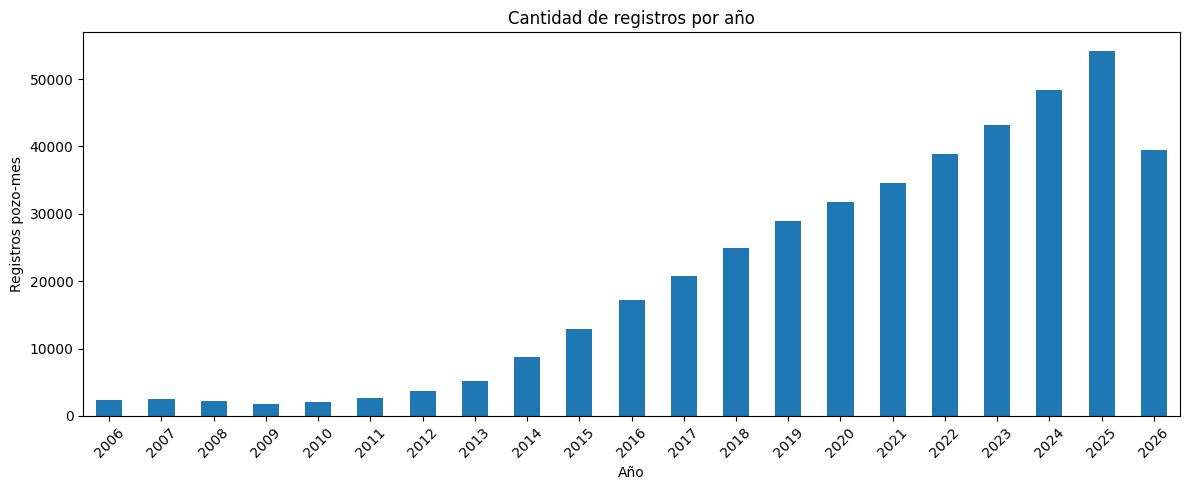

In [ ]:
registros_por_anio=df.groupby("anio").size()
ax=registros_por_anio.plot(kind="bar",figsize=(12,5))
ax.set(title="Cantidad de registros por año",xlabel="Año",ylabel="Registros pozo-mes")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### Interpretación
La base cubre **enero de 2006 a agosto de 2026** y las variables temporales son consistentes. Debe recordarse que 2026 es un año incompleto.

# 5. Cobertura geográfica

### ¿Qué queremos averiguar?
Compararemos registros y pozos por cuenca para decidir si el proyecto debe abarcar toda Argentina o enfocarse en la **Cuenca Neuquina**.

,registros,registros_%,pozos
cuenca,,,
NEUQUINA,408912,95.960,4899
AUSTRAL,16406,3.850,209
GOLFO SAN JORGE,642,0.150,15
NOROESTE,185,0.040,3


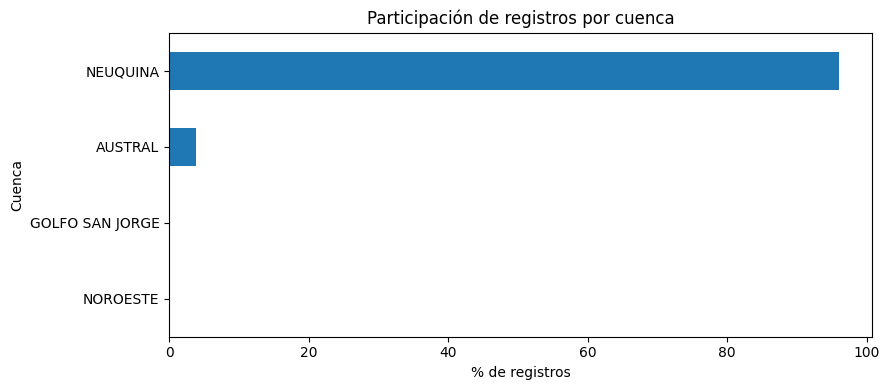

In [ ]:
reg=df.groupby("cuenca").size().rename("registros").to_frame()
reg["registros_%"]=(reg["registros"]/len(df)*100).round(2)
pozos=df.groupby("cuenca")["idpozo"].nunique().rename("pozos")
resumen_cuencas=reg.join(pozos).sort_values("registros",ascending=False)
display(resumen_cuencas)
ax=resumen_cuencas["registros_%"].sort_values().plot(kind="barh",figsize=(9,4))
ax.set(title="Participación de registros por cuenca",xlabel="% de registros",ylabel="Cuenca"); plt.tight_layout(); plt.show()

In [ ]:
prov_nqn=df.loc[df["cuenca"].eq("NEUQUINA"),"provincia"].value_counts().rename_axis("provincia").to_frame("registros")
prov_nqn["registros_%"]=(prov_nqn["registros"]/prov_nqn["registros"].sum()*100).round(2)
display(prov_nqn)

,registros,registros_%
provincia,,
Neuquén,376072,91.970
Rio Negro,29659,7.250
Mendoza,3181,0.780


### Interpretación y decisión de alcance
La **Cuenca Neuquina concentra aproximadamente el 96 % de los registros** y cerca del 95,6 % de los pozos. El proyecto se enfocará en esta cuenca. El filtro correcto es `cuenca == "NEUQUINA"`, no `provincia == "Neuquén"`, porque la cuenca también contiene registros de Río Negro y Mendoza.

# 6. Universo principal: Cuenca Neuquina

### ¿Qué queremos averiguar?
Creamos una copia específica para el universo elegido, manteniendo `df` como fuente completa para trazabilidad.

In [ ]:
df_nqn=df.loc[df["cuenca"].eq("NEUQUINA")].copy()
print(f"Registros Argentina: {len(df):,}")
print(f"Registros Cuenca Neuquina: {len(df_nqn):,}")
print(f"Pozos Cuenca Neuquina: {df_nqn['idpozo'].nunique():,}")
print(f"Participación: {len(df_nqn)/len(df)*100:.2f}%")

Registros Argentina: 426,145
Registros Cuenca Neuquina: 408,912
Pozos Cuenca Neuquina: 4,899
Participación: 95.96%


### Interpretación
Quedan aproximadamente **408.912 registros y 4.899 pozos**, un volumen ampliamente suficiente para EDA y futuros modelos.

# 7. Valores faltantes

### ¿Qué queremos averiguar?
Cuantificaremos los nulos dentro del universo seleccionado. La ausencia de nulos no garantiza calidad; después estudiaremos ceros, negativos y extremos.

,nulos,nulos_%
vida_util,400407,97.920
observaciones,385100,94.180
tipopozo,598,0.150
tipoextraccion,598,0.150
tipoestado,598,0.150
sub_tipo_recurso,114,0.030
idempresa,0,0.000
anio,0,0.000
iny_agua,0,0.000
prod_agua,0,0.000


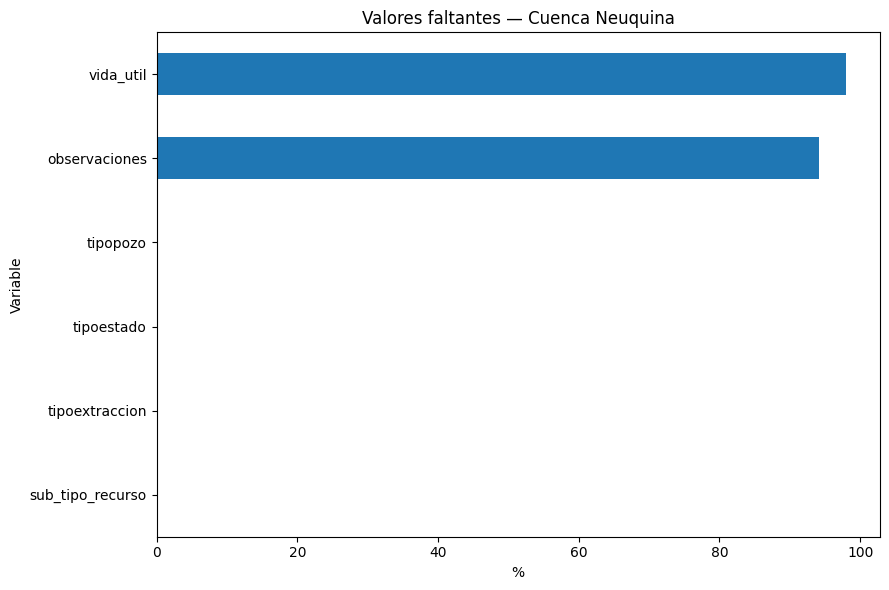

In [ ]:
missing=pd.DataFrame({"nulos":df_nqn.isna().sum(),"nulos_%":(df_nqn.isna().mean()*100).round(2)}).sort_values("nulos_%",ascending=False)
display(missing)
mp=missing.loc[missing["nulos_%"]>0,"nulos_%"].sort_values()
if len(mp):
    ax=mp.plot(kind="barh",figsize=(9,6)); ax.set(title="Valores faltantes — Cuenca Neuquina",xlabel="%",ylabel="Variable"); plt.tight_layout(); plt.show()

### Interpretación
Las variables productivas principales tienen alta completitud. `vida_util` y `observaciones` son las principales excepciones.

# 8. Integridad numérica y valores extremos

### ¿Qué queremos averiguar?
Buscamos valores negativos, ceros y extremos. Los outliers no se eliminarán automáticamente: primero deben interpretarse desde el dominio.

In [ ]:
vars_num=["prod_pet","prod_gas","prod_agua","iny_agua","iny_gas","iny_co2","iny_otro","tef","profundidad"]
control=pd.DataFrame({
 "min":df_nqn[vars_num].min(),"p01":df_nqn[vars_num].quantile(.01),"mediana":df_nqn[vars_num].median(),
 "p99":df_nqn[vars_num].quantile(.99),"max":df_nqn[vars_num].max(),
 "ceros_%":((df_nqn[vars_num]==0).mean()*100).round(2),"negativos":(df_nqn[vars_num]<0).sum()})
display(control)

,min,p01,mediana,p99,max,ceros_%,negativos
prod_pet,0.000,0.000,7.330,"4,987.259","26,593.261",35.960,0
prod_gas,-12.267,0.000,95.460,"8,930.415","40,086.800",20.880,2
prod_agua,0.000,0.000,12.260,"3,206.232","34,792.950",30.630,0
iny_agua,0.000,0.000,0.000,0.000,"70,278.850",99.840,0
iny_gas,0.000,0.000,0.000,0.000,"3,569,000.000",99.850,0
iny_co2,0.000,0.000,0.000,0.000,0.000,100.000,0
iny_otro,0.000,0.000,0.000,0.000,0.000,100.000,0
tef,0.000,0.000,29.210,31.000,79.340,19.730,0
profundidad,0.000,0.000,"3,370.000","6,736.000","378,939.000",1.440,0


In [ ]:
negativos_prod=df_nqn.loc[(df_nqn["prod_pet"]<0)|(df_nqn["prod_gas"]<0)|(df_nqn["prod_agua"]<0),["idpozo","fecha_data","prod_pet","prod_gas","prod_agua","empresa","areapermisoconcesion"]]
display(negativos_prod)
for col in ["profundidad","tef"]:
    print(f"\nTop 10 — {col}")
    display(df_nqn.nlargest(10,col)[["idpozo","fecha_data",col,"empresa","formacion","areapermisoconcesion"]])

,idpozo,fecha_data,prod_pet,prod_gas,prod_agua,empresa,areapermisoconcesion
304525,153228,2020-05-31,1.670,-12.267,0.000,PLUSPETROL S.A.,CENTENARIO CENTRO
304545,153227,2020-05-31,1.020,-7.519,0.000,PLUSPETROL S.A.,CENTENARIO CENTRO



Top 10 — profundidad


,idpozo,fecha_data,profundidad,empresa,formacion,areapermisoconcesion
74,156804,2017-01-31,"378,939.000",YSUR ENERGÍA ARGENTINA S.R.L.,lajas,ESTACION FERNANDEZ ORO
327,156804,2018-01-31,"378,939.000",YSUR ENERGÍA ARGENTINA S.R.L.,lajas,ESTACION FERNANDEZ ORO
838,156804,2018-02-28,"378,939.000",YSUR ENERGÍA ARGENTINA S.R.L.,lajas,ESTACION FERNANDEZ ORO
1007,156804,2017-02-28,"378,939.000",YSUR ENERGÍA ARGENTINA S.R.L.,lajas,ESTACION FERNANDEZ ORO
1621,156804,2018-03-31,"378,939.000",YSUR ENERGÍA ARGENTINA S.R.L.,lajas,ESTACION FERNANDEZ ORO
2027,156804,2017-03-31,"378,939.000",YSUR ENERGÍA ARGENTINA S.R.L.,lajas,ESTACION FERNANDEZ ORO
2741,156804,2018-04-30,"378,939.000",YSUR ENERGÍA ARGENTINA S.R.L.,lajas,ESTACION FERNANDEZ ORO
2744,156804,2017-04-30,"378,939.000",YSUR ENERGÍA ARGENTINA S.R.L.,lajas,ESTACION FERNANDEZ ORO
2832,156804,2017-05-31,"378,939.000",YSUR ENERGÍA ARGENTINA S.R.L.,lajas,ESTACION FERNANDEZ ORO
3186,156804,2018-05-31,"378,939.000",YSUR ENERGÍA ARGENTINA S.R.L.,lajas,ESTACION FERNANDEZ ORO



Top 10 — tef


,idpozo,fecha_data,tef,empresa,formacion,areapermisoconcesion
285033,154790,2019-05-31,79.340,SHELL ARGENTINA S.A.,vaca muerta,SIERRAS BLANCAS
380245,10073,2006-12-31,58.770,CHEVRON ARGENTINA S.R.L.,lajas,LOMA NEGRA
370773,145043,2017-02-28,46.880,O&G DEVELOPMENTS LTD S.A.,vaca muerta,SIERRAS BLANCAS
286094,161531,2021-06-30,36.670,SHELL ARGENTINA S.A.,vaca muerta,SIERRAS BLANCAS
286103,161532,2021-06-30,36.670,SHELL ARGENTINA S.A.,vaca muerta,SIERRAS BLANCAS
398495,126809,2008-01-31,32.000,CAPEX S.A.,los molles,AGUA DEL CAJON
402761,126809,2008-03-31,32.000,CAPEX S.A.,los molles,AGUA DEL CAJON
406328,126809,2008-05-31,32.000,CAPEX S.A.,los molles,AGUA DEL CAJON
411476,126809,2008-08-31,32.000,CAPEX S.A.,los molles,AGUA DEL CAJON
415234,126809,2007-10-31,32.000,CAPEX S.A.,los molles,AGUA DEL CAJON


### Interpretación
Hay muy pocos valores negativos en producción y algunos máximos que requieren revisión técnica. `profundidad` y `tef` muestran casos extremos que deben validarse con reglas de dominio, no con eliminación ciega por percentiles.

# 9. Distribución de petróleo, gas y agua

### ¿Qué queremos averiguar?
Visualizaremos las distribuciones con `log1p` para representar ceros y valores altos sin modificar permanentemente los datos.

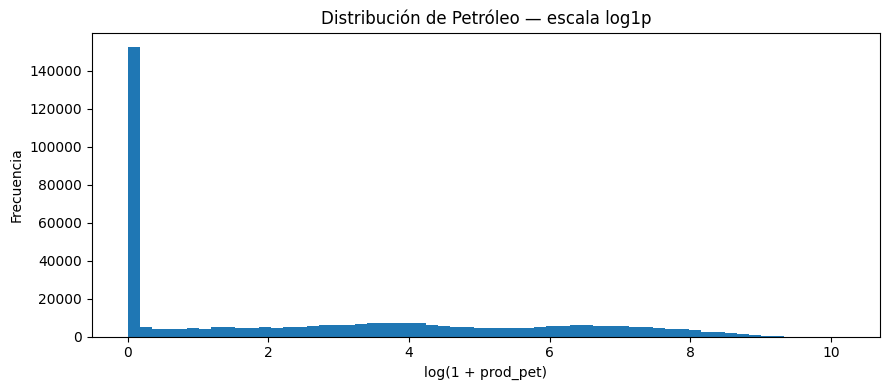

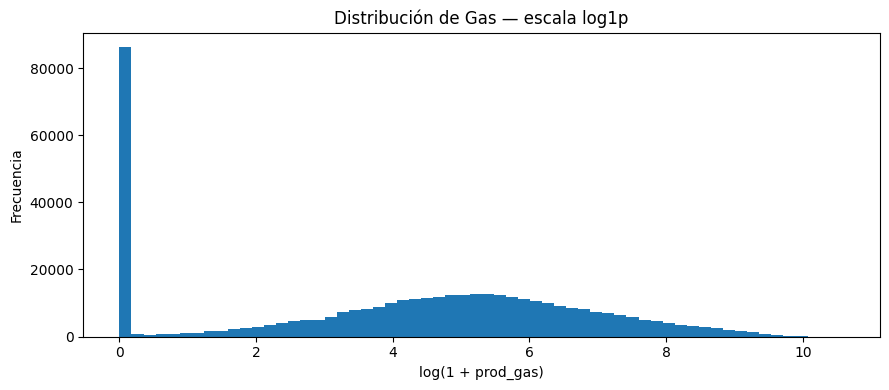

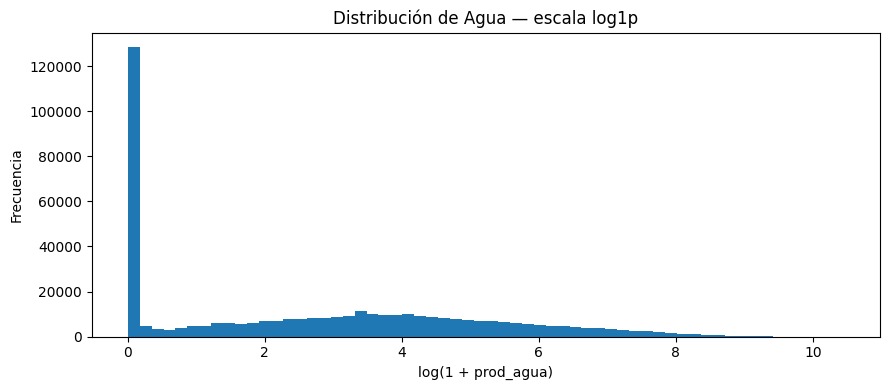

In [ ]:
for col, etiqueta in [("prod_pet", "Petróleo"), ("prod_gas", "Gas"), ("prod_agua", "Agua")]:
    serie_log = np.log1p(df_nqn[col].clip(lower=0))
    ax = serie_log.plot.hist(bins=60, figsize=(9, 4))
    ax.set(
        title=f"Distribución de {etiqueta} — escala log1p",
        xlabel=f"log(1 + {col})",
        ylabel="Frecuencia"
    )
    plt.tight_layout()
    plt.show()


### Interpretación
Las distribuciones son fuertemente asimétricas. Al modelar habrá que elegir métricas que no queden dominadas por unos pocos pozos extremos y evaluar transformaciones del target.

# 10. Composición Shale vs Tight

### ¿Qué queremos averiguar?
Cuantificamos los subtipos de recurso y verificamos si `sub_tipo_recurso` se mantiene estable por pozo.

In [ ]:
subtipo=df_nqn["sub_tipo_recurso"].value_counts(dropna=False).rename_axis("sub_tipo_recurso").to_frame("registros")
subtipo["registros_%"]=(subtipo["registros"]/len(df_nqn)*100).round(2)
display(subtipo)
subtipos_pozo=df_nqn.groupby("idpozo")["sub_tipo_recurso"].nunique(dropna=True)
print(f"Pozos con más de un subtipo: {(subtipos_pozo>1).sum():,}")

,registros,registros_%
sub_tipo_recurso,,
SHALE,227185,55.560
TIGHT,181613,44.410
NaN,114,0.030


Pozos con más de un subtipo: 0


### Interpretación
SHALE y TIGHT tienen representación importante y el subtipo se comporta como atributo estable del pozo. Es una feature categórica potencialmente útil.

# 11. Evolución temporal de la producción agregada

### ¿Qué queremos averiguar?
Observamos el contexto histórico de producción mensual. Petróleo, gas y agua se grafican por separado porque poseen unidades distintas.

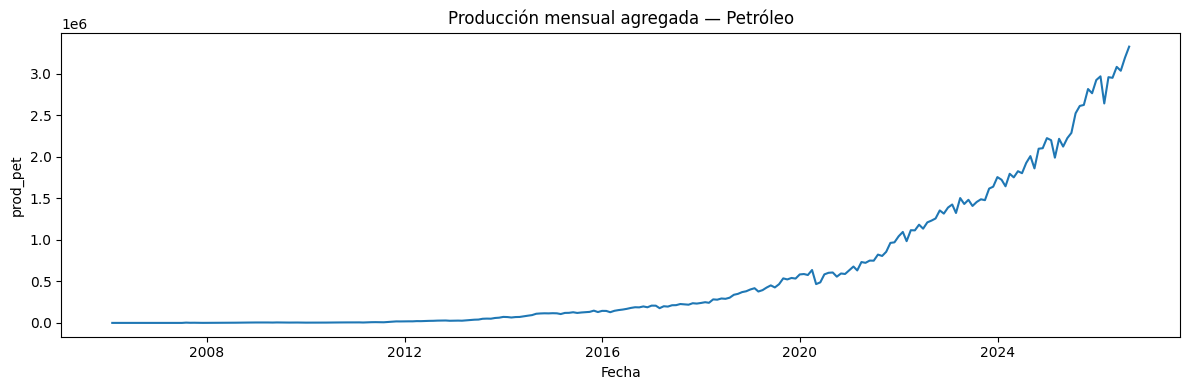

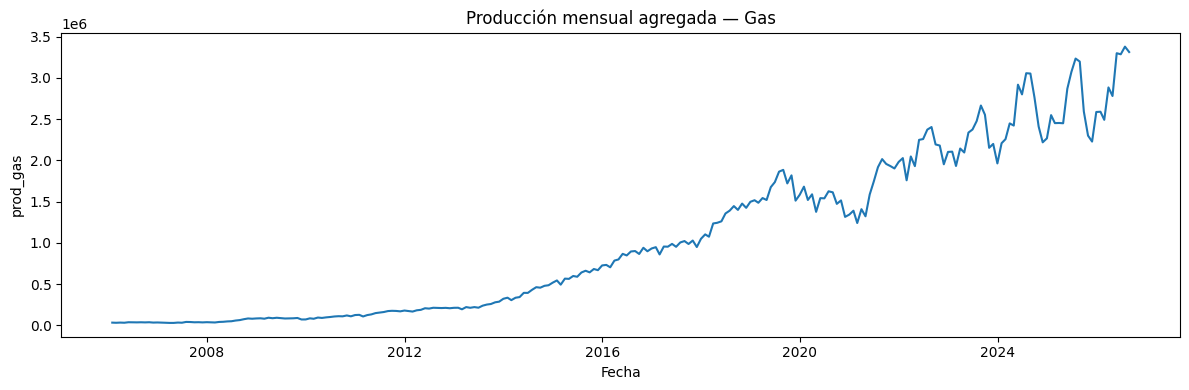

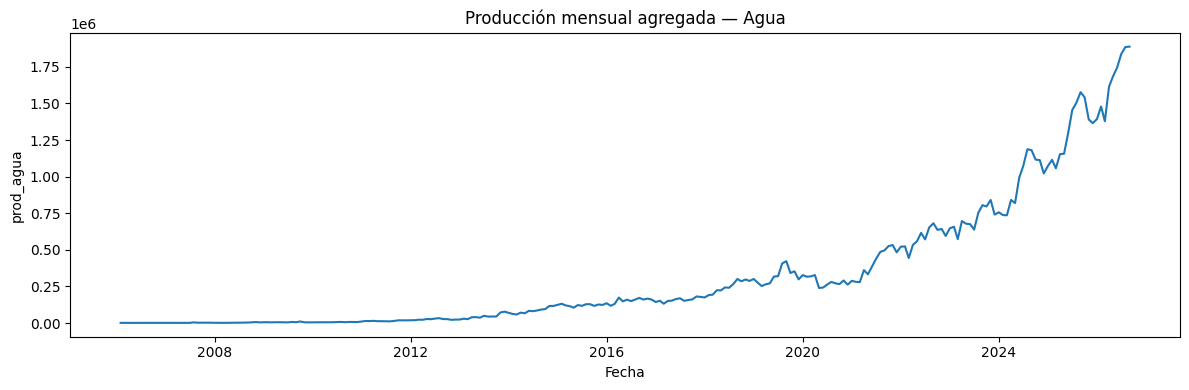

In [ ]:
prod_mensual = (
    df_nqn.groupby("fecha_data")[["prod_pet", "prod_gas", "prod_agua"]]
    .sum()
    .sort_index()
)

for col, titulo in [("prod_pet", "Petróleo"), ("prod_gas", "Gas"), ("prod_agua", "Agua")]:
    ax = prod_mensual[col].plot(figsize=(12, 4))
    ax.set(
        title=f"Producción mensual agregada — {titulo}",
        xlabel="Fecha",
        ylabel=col
    )
    plt.tight_layout()
    plt.show()


### Interpretación
Estas series contextualizan el desarrollo no convencional, pero no son curvas de declinación de pozo porque combinan pozos de distintas edades y nuevas incorporaciones.

# 12. Historia disponible por pozo

### ¿Qué queremos averiguar?
Antes de formular un target necesitamos saber cuántos pozos poseen al menos 6, 12, 18 o 24 registros mensuales.

,meses_minimos,pozos,pozos_%
0,6,4650,94.920
1,12,4426,90.340
2,18,4156,84.830
3,24,3964,80.910
4,36,3508,71.610
5,60,2821,57.580


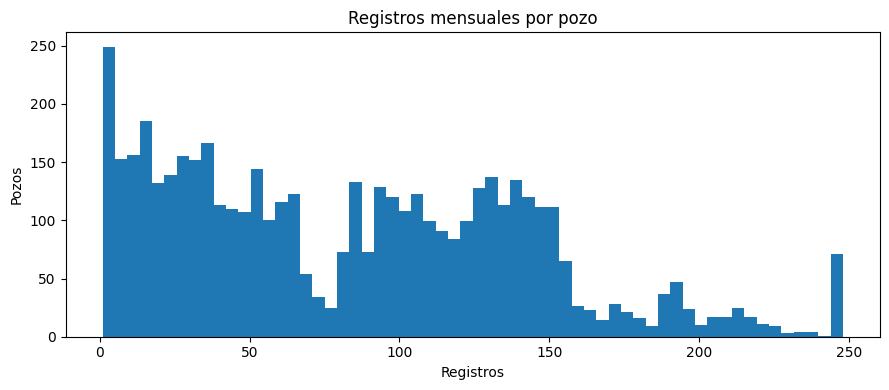

In [ ]:
registros_pozo = df_nqn.groupby("idpozo").size()
h = [6, 12, 18, 24, 36, 60]
resumen_historia = pd.DataFrame({
    "meses_minimos": h,
    "pozos": [(registros_pozo >= x).sum() for x in h]
})
resumen_historia["pozos_%"] = (
    resumen_historia["pozos"] / df_nqn["idpozo"].nunique() * 100
).round(2)

display(resumen_historia)

ax = registros_pozo.plot.hist(bins=60, figsize=(9, 4))
ax.set(title="Registros mensuales por pozo", xlabel="Registros", ylabel="Pozos")
plt.tight_layout()
plt.show()


### Interpretación
Existen aproximadamente **4.650 pozos con ≥6 registros, 4.426 con ≥12, 4.156 con ≥18 y 3.964 con ≥24**. La cobertura es amplia, pero los primeros N registros no necesariamente son los primeros N meses productivos.

# 13. Definición preliminar del inicio productivo

### ¿Qué queremos averiguar?
Como primera aproximación definimos un mes productivo cuando `prod_pet > 0` **o** `prod_gas > 0`.

In [ ]:
df_nqn["es_mes_productivo"]=(df_nqn["prod_pet"]>0)|(df_nqn["prod_gas"]>0)
primer_mes=df_nqn.loc[df_nqn["es_mes_productivo"]].groupby("idpozo")["fecha_data"].min().rename("fecha_inicio_prod")
print(f"Pozos totales: {df_nqn['idpozo'].nunique():,}")
print(f"Con al menos un mes productivo: {primer_mes.size:,}")
print(f"Sin producción positiva PET/GAS: {df_nqn['idpozo'].nunique()-primer_mes.size:,}")

Pozos totales: 4,899
Con al menos un mes productivo: 4,729
Sin producción positiva PET/GAS: 170


In [ ]:
df_hist=df_nqn.merge(primer_mes,left_on="idpozo",right_index=True,how="left")
df_hist=df_hist.loc[df_hist["fecha_inicio_prod"].notna()].copy()
df_hist["mes_relativo"]=(df_hist["fecha_data"].dt.year-df_hist["fecha_inicio_prod"].dt.year)*12+(df_hist["fecha_data"].dt.month-df_hist["fecha_inicio_prod"].dt.month)+1
df_hist=df_hist.loc[df_hist["mes_relativo"]>=1].copy()
display(df_hist[["idpozo","fecha_data","fecha_inicio_prod","mes_relativo","prod_pet","prod_gas"]].sort_values(["idpozo","fecha_data"]).head(20))

,idpozo,fecha_data,fecha_inicio_prod,mes_relativo,prod_pet,prod_gas
318284,3640,2006-03-31,2006-03-31,1,30.808,1.731
318385,3640,2006-04-30,2006-03-31,2,76.609,3.713
318440,3640,2006-05-31,2006-03-31,3,63.273,4.202
318523,3640,2006-06-30,2006-03-31,4,55.043,4.373
318622,3640,2006-07-31,2006-03-31,5,58.862,3.732
318685,3640,2006-08-31,2006-03-31,6,33.241,3.212
318765,3640,2006-09-30,2006-03-31,7,37.288,5.669
318834,3640,2006-10-31,2006-03-31,8,64.166,5.006
318951,3640,2006-11-30,2006-03-31,9,62.857,2.755
319000,3640,2006-12-31,2006-03-31,10,66.644,3.619


### Interpretación
`mes_relativo = 1` representa el mes calendario de inicio productivo. Este eje respeta el calendario y permite detectar huecos, evitando confundir número de registro con edad productiva.

# 14. Ventanas continuas disponibles

### ¿Qué queremos averiguar?
Para predecir meses 7–12 usando 1–6 necesitamos meses calendario observados, no sólo una cantidad total de registros.

In [ ]:
filas=[]
for horizonte in [6,12,18,24]:
    obs=df_hist.loc[df_hist["mes_relativo"].between(1,horizonte)].groupby("idpozo")["mes_relativo"].nunique()
    filas.append({"horizonte_meses":horizonte,"pozos_con_ventana_completa":int((obs>=horizonte).sum())})
ventanas=pd.DataFrame(filas)
ventanas["%_sobre_pozos_productivos"]=(ventanas["pozos_con_ventana_completa"]/primer_mes.size*100).round(2)
display(ventanas)

,horizonte_meses,pozos_con_ventana_completa,%_sobre_pozos_productivos
0,6,4459,94.290
1,12,4172,88.220
2,18,3879,82.030
3,24,3665,77.500


### Interpretación
Hay aproximadamente **4.459 pozos** con los primeros 6 meses calendario observados, **4.172** con 12, **3.879** con 18 y **3.665** con 24. Esto respalda una formulación como usar meses 1–6 para predecir producción futura de meses 7–12.

# 15. Curvas alineadas por edad productiva

### ¿Qué queremos averiguar?
Comparamos media y mediana de producción durante los primeros 36 meses desde el inicio productivo.

,pet_mediana,pet_media,gas_mediana,gas_media,pozos
mes_relativo,,,,,
1,109.860,516.094,148.920,740.184,4729
2,824.880,"1,777.612",576.760,"2,094.589",4678
3,837.830,"2,200.269",729.345,"2,458.516",4632
4,715.760,"2,165.889",748.661,"2,441.891",4592
5,629.840,"1,938.384",679.481,"2,262.386",4520
6,507.555,"1,682.309",620.773,"2,106.778",4470
7,459.230,"1,461.243",545.360,"1,967.112",4423
8,377.895,"1,294.641",483.835,"1,793.393",4372
9,324.115,"1,159.657",439.540,"1,659.070",4346


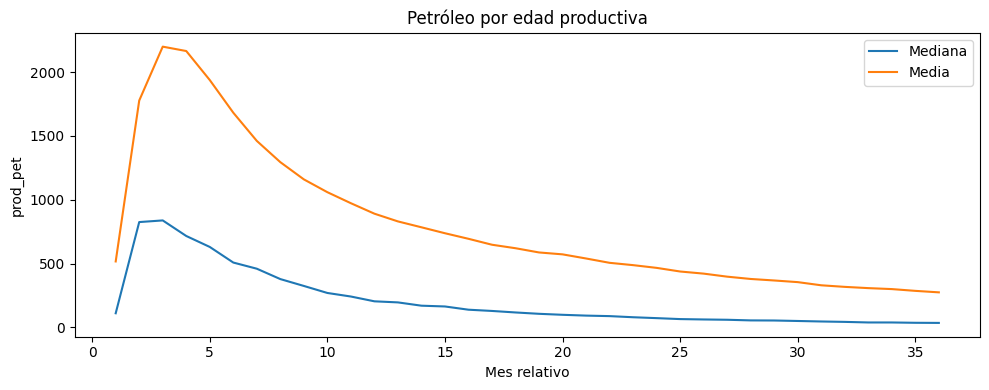

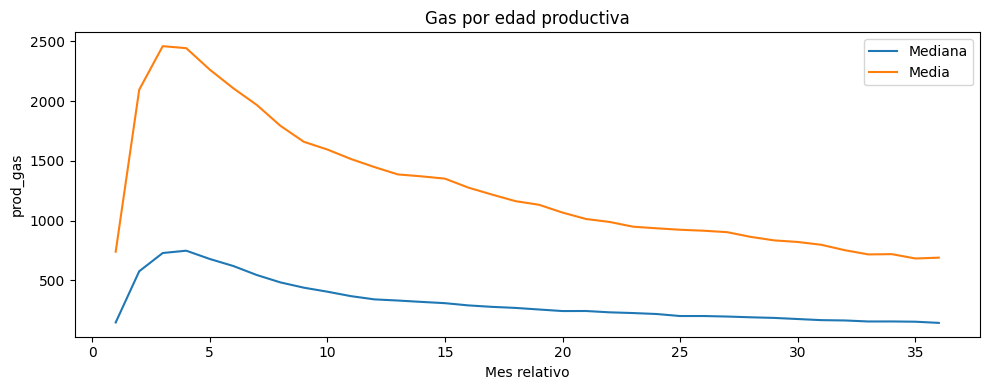

In [ ]:
curvas = (
    df_hist.loc[df_hist["mes_relativo"].between(1, 36)]
    .groupby("mes_relativo")
    .agg(
        pet_mediana=("prod_pet", "median"),
        pet_media=("prod_pet", "mean"),
        gas_mediana=("prod_gas", "median"),
        gas_media=("prod_gas", "mean"),
        pozos=("idpozo", "nunique")
    )
)

display(curvas.head(12))

for med, media, titulo, y in [
    ("pet_mediana", "pet_media", "Petróleo por edad productiva", "prod_pet"),
    ("gas_mediana", "gas_media", "Gas por edad productiva", "prod_gas")
]:
    ax = (
        curvas[[med, media]]
        .rename(columns={med: "Mediana", media: "Media"})
        .plot(figsize=(10, 4))
    )
    ax.set(title=titulo, xlabel="Mes relativo", ylabel=y)
    plt.tight_layout()
    plt.show()


### Interpretación
Alinear por edad productiva permite observar patrones que quedan ocultos en las series calendario. La diferencia entre media y mediana evidencia heterogeneidad entre pozos.

# 16. Variables candidatas y riesgo de data leakage

### ¿Qué queremos averiguar?
La **fecha de corte** de cada predicción debe actuar como frontera de información: ninguna feature puede usar datos posteriores.

**Posibles estáticas:** profundidad, formación, área, provincia, subtipo de recurso, coordenadas y cohorte de inicio.  
**Derivadas de meses 1–6:** acumulados, máximos, promedios, tendencias, TEF y meses efectivos.  
**Con precaución:** empresa, estado, extracción, habilitación y otras variables que puedan cambiar durante la vida del pozo.

In [ ]:
atributos=["sub_tipo_recurso","formacion","areapermisoconcesion","provincia","empresa"]
filas=[]
for col in atributos:
    n=df_nqn.groupby("idpozo")[col].nunique(dropna=True)
    filas.append({"variable":col,"pozos_con_mas_de_un_valor":int((n>1).sum()),"max_valores_en_un_pozo":int(n.max())})
display(pd.DataFrame(filas))

,variable,pozos_con_mas_de_un_valor,max_valores_en_un_pozo
0,sub_tipo_recurso,0,1
1,formacion,0,1
2,areapermisoconcesion,0,1
3,provincia,0,1
4,empresa,981,6


### Interpretación
Formación, área y subtipo son mucho más estables que `empresa`, que puede cambiar con el tiempo. Para evitar leakage, cualquier variable temporal deberá tomarse sólo hasta la fecha de corte.

# 17. Conclusiones del EDA inicial

1. **Granularidad validada:** una fila representa un pozo-mes y `idpozo + anio + mes` es único.  
2. **Cobertura extensa:** enero de 2006 a agosto de 2026.  
3. **Alcance:** el proyecto se enfocará en la **Cuenca Neuquina**, con ~96 % de las observaciones.  
4. **Calidad general:** buena completitud productiva, con `vida_util`, `observaciones` y ciertos valores extremos a revisar.  
5. **Viabilidad longitudinal:** miles de pozos poseen ventanas continuas suficientes.  
6. **Inicio productivo:** se propuso el primer mes con petróleo o gas positivo y se construyó `mes_relativo`.  
7. **Leakage:** las futuras features deberán respetar estrictamente la fecha de corte.

## Próximo paso
El siguiente notebook debería abordar **preparación de datos y definición formal del problema predictivo**. Una hipótesis inicial a evaluar es:

> **Utilizar la información disponible durante los primeros 6 meses productivos de un pozo para predecir su producción acumulada futura entre los meses 7 y 12.**

Antes de adoptarla definitivamente habrá que comparar alternativas para petróleo y gas, definir criterios para huecos temporales y documentar el tratamiento de anomalías.

# 18. Propuesta de acotamiento del universo de análisis

### ¿Qué queremos averiguar?
El EDA inicial confirmó que el dataset completo es amplio y heterogéneo. Antes de avanzar al modelado conviene evaluar si podemos construir un problema más específico, físicamente comparable y operacionalmente interpretable.

Como **alcance preliminar** se propone trabajar con:

- **Cuenca:** Neuquina
- **Tipo de pozo:** Gasífero
- **Subtipo de recurso:** Shale
- **Formación:** Vaca Muerta

La hipótesis de trabajo asociada sería:

> **Utilizar la información disponible durante los primeros 6 meses de producción de gas para predecir el desempeño gasífero futuro del pozo, inicialmente medido como producción acumulada entre los meses 7 y 12.**

El siguiente bloque cuantifica cuánto reduce este recorte el universo original y verifica que continúe existiendo una cantidad suficiente de pozos con historia mensual.


In [ ]:
# Normalizamos únicamente para construir filtros robustos a mayúsculas/minúsculas y espacios.
cuenca_norm = df["cuenca"].astype("string").str.strip().str.upper()
tipopozo_norm = df["tipopozo"].astype("string").str.strip().str.casefold()
subtipo_norm = df["sub_tipo_recurso"].astype("string").str.strip().str.upper()
formacion_norm = df["formacion"].astype("string").str.strip().str.casefold()

mask_nqn = cuenca_norm.eq("NEUQUINA")
mask_gas = tipopozo_norm.eq("gasífero".casefold())
mask_shale = subtipo_norm.eq("SHALE")
mask_vm = formacion_norm.eq("vaca muerta")

etapas = [
    ("Dataset completo", pd.Series(True, index=df.index)),
    ("Cuenca Neuquina", mask_nqn),
    ("+ Pozos gasíferos", mask_nqn & mask_gas),
    ("+ Shale", mask_nqn & mask_gas & mask_shale),
    ("+ Formación Vaca Muerta", mask_nqn & mask_gas & mask_shale & mask_vm),
]

resumen_recorte = []
for etapa, mascara in etapas:
    aux = df.loc[mascara]
    resumen_recorte.append({
        "etapa": etapa,
        "registros": len(aux),
        "pozos": aux["idpozo"].nunique(),
        "%_registros_original": round(len(aux) / len(df) * 100, 2),
    })

resumen_recorte = pd.DataFrame(resumen_recorte)
display(resumen_recorte)

# Universo propuesto
mask_universo = mask_nqn & mask_gas & mask_shale & mask_vm
df_gas_shale_vm = df.loc[mask_universo].copy()

# Historia disponible por pozo dentro del nuevo universo
registros_por_pozo_scope = df_gas_shale_vm.groupby("idpozo").size()
historia_scope = pd.DataFrame({
    "meses_minimos": [6, 12, 18, 24],
    "pozos": [
        int((registros_por_pozo_scope >= h).sum())
        for h in [6, 12, 18, 24]
    ],
})
historia_scope["%_sobre_pozos_scope"] = (
    historia_scope["pozos"] / df_gas_shale_vm["idpozo"].nunique() * 100
).round(2)

display(historia_scope)

print(f"Registros del universo propuesto: {len(df_gas_shale_vm):,}")
print(f"Pozos únicos del universo propuesto: {df_gas_shale_vm['idpozo'].nunique():,}")
print(
    "Reducción de registros respecto del dataset original: "
    f"{(1 - len(df_gas_shale_vm) / len(df)) * 100:.2f}%"
)


,etapa,registros,pozos,%_registros_original
0,Dataset completo,426145,5126,100.000
1,Cuenca Neuquina,408912,4899,95.960
2,+ Pozos gasíferos,214121,2263,50.250
3,+ Shale,46894,876,11.000
4,+ Formación Vaca Muerta,46280,867,10.860


,meses_minimos,pozos,%_sobre_pozos_scope
0,6,809,93.310
1,12,755,87.080
2,18,708,81.660
3,24,675,77.850


Registros del universo propuesto: 46,280
Pozos únicos del universo propuesto: 867
Reducción de registros respecto del dataset original: 89.14%


### Interpretación

Con la versión actual del dataset, el recorte propuesto deja aproximadamente **46 mil registros correspondientes a 867 pozos**, es decir, cerca del **11 % de las filas originales**. En otras palabras, reduce el volumen de trabajo en casi un 90 % sin llevar el universo a un tamaño demasiado pequeño.

Además, alrededor de **755 pozos poseen al menos 12 registros mensuales**, por lo que existe una base razonable para estudiar una ventana inicial de 6 meses y un horizonte posterior de 6 meses.

Este recorte también mejora la comparabilidad física del problema: evita mezclar simultáneamente pozos petrolíferos y gasíferos, recursos tight y shale, y formaciones con comportamientos productivos diferentes.

Por lo tanto, el **scope preliminar V1** del proyecto queda planteado como:

> **Predicción del desempeño productivo futuro de pozos gasíferos shale de Vaca Muerta a partir de sus primeros seis meses de producción.**

La definición exacta del inicio productivo, las ventanas continuas y el target se formalizarán en el Notebook 02.


## 18.1 Visualizaciones del universo propuesto con Pandas

### ¿Qué queremos averiguar?
Una vez definido el recorte **Cuenca Neuquina + Gasífero + Shale + Vaca Muerta**, conviene verificar visualmente que el subconjunto conserva una historia temporal suficientemente rica y observar cómo evolucionó la producción de gas agregada.

Estas visualizaciones se construyen con los métodos de graficación de **Pandas** (`Series.plot` / `DataFrame.plot`), utilizando Matplotlib únicamente como backend para el formato final.


In [ ]:
# Evolución de la producción mensual de gas en el universo propuesto
gas_mensual_scope = (
    df_scope.groupby("fecha_data")["prod_gas"]
    .sum()
    .sort_index()
)

ax = gas_mensual_scope.plot(figsize=(12, 4))
ax.set(
    title="Producción mensual agregada de gas — Gasíferos Shale de Vaca Muerta",
    xlabel="Fecha",
    ylabel="Producción de gas"
)
plt.tight_layout()
plt.show()

# Cantidad de pozos con registros por año
pozos_por_anio_scope = df_scope.groupby("anio")["idpozo"].nunique()

ax = pozos_por_anio_scope.plot(kind="bar", figsize=(12, 4))
ax.set(
    title="Pozos gasíferos shale de Vaca Muerta con registros por año",
    xlabel="Año",
    ylabel="Cantidad de pozos"
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Interpretación

Estas dos visualizaciones permiten vincular el recorte metodológico con el objetivo del proyecto: el subconjunto conserva una serie temporal amplia y una cantidad de pozos suficiente para continuar con análisis longitudinales. En las siguientes etapas, las curvas deberán alinearse por **edad productiva del pozo** y no solamente por fecha calendario, para que la comparación entre trayectorias sea consistente.


# 19. Generación del dataset analítico reducido

### ¿Qué queremos hacer?
Una vez justificado el recorte, no es necesario volver a cargar las ~426 mil filas del dataset original para cada etapa posterior del proyecto.

Generaremos un archivo derivado con:

1. Solo el universo **Neuquina + Gasífero + Shale + Vaca Muerta**.
2. Las variables con potencial analítico, productivo o de trazabilidad.
3. Compresión `gzip`, que pandas puede leer directamente sin descomprimir manualmente.

El dataset original **no se modifica**. El nuevo archivo es un producto procesado y reproducible de este Notebook 01.

### Variables conservadas
Se mantienen variables temporales, productivas, operativas, geográficas y de identificación. También se conservan `cuenca`, `tipopozo`, `sub_tipo_recurso` y `formacion` para que el archivo sea autodescriptivo.

Estas últimas cuatro variables son constantes por construcción dentro del nuevo universo, por lo que **no deberán utilizarse como features predictivas**.


In [ ]:
from pathlib import Path

columnas_dataset_analitico = [
    # Identificación y tiempo
    "idpozo", "anio", "mes", "fecha_data",

    # Producción
    "prod_gas", "prod_pet", "prod_agua", "tef",

    # Características / contexto del pozo
    "profundidad", "empresa", "sigla",
    "tipoextraccion", "tipoestado", "formprod",

    # Área y localización
    "areapermisoconcesion", "areayacimiento", "provincia",
    "coordenadax", "coordenaday",

    # Clasificación
    "clasificacion", "subclasificacion",

    # Trazabilidad del recorte
    "cuenca", "tipopozo", "sub_tipo_recurso", "formacion",
]

# Control defensivo: confirmar que todas las columnas existan.
faltantes = [c for c in columnas_dataset_analitico if c not in df_gas_shale_vm.columns]
if faltantes:
    raise KeyError(f"Faltan columnas esperadas en el dataset: {faltantes}")

df_analitico = (
    df_gas_shale_vm[columnas_dataset_analitico]
    .sort_values(["idpozo", "anio", "mes"])
    .reset_index(drop=True)
)

OUTPUT_DIR = Path("/content/data_processed")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "gas_shale_vaca_muerta.csv.gz"

df_analitico.to_csv(
    OUTPUT_PATH,
    index=False,
    compression="gzip",
)

tamano_mb = OUTPUT_PATH.stat().st_size / (1024 ** 2)

print(f"Archivo generado: {OUTPUT_PATH}")
print(f"Dimensiones: {df_analitico.shape[0]:,} filas x {df_analitico.shape[1]} columnas")
print(f"Pozos únicos: {df_analitico['idpozo'].nunique():,}")
print(f"Tamaño comprimido: {tamano_mb:.2f} MiB")

display(df_analitico.head())


Archivo generado: /content/data_processed/gas_shale_vaca_muerta.csv.gz
Dimensiones: 46,280 filas x 25 columnas
Pozos únicos: 867
Tamaño comprimido: 0.83 MiB


,idpozo,anio,mes,fecha_data,prod_gas,prod_pet,prod_agua,tef,profundidad,empresa,sigla,tipoextraccion,tipoestado,formprod,areapermisoconcesion,areayacimiento,provincia,coordenadax,coordenaday,clasificacion,subclasificacion,cuenca,tipopozo,sub_tipo_recurso,formacion
0,8043,2006,1,2006-01-31,0.000,0.000,0.000,0.000,"3,243.000",TECPETROL S.A.,YPF.Nq.FP.x-2,Sin Sistema de Extracción,En Reserva de Gas,VMUT,FORTIN DE PIEDRA,FORTIN DE PIEDRA,Neuquén,-69.039,-38.508,EXPLORACION,EXPLORACION,NEUQUINA,Gasífero,SHALE,vaca muerta
1,8043,2006,2,2006-02-28,0.000,0.000,0.000,0.000,"3,243.000",TECPETROL S.A.,YPF.Nq.FP.x-2,Sin Sistema de Extracción,A Abandonar,VMUT,FORTIN DE PIEDRA,FORTIN DE PIEDRA,Neuquén,-69.039,-38.508,EXPLORACION,EXPLORACION,NEUQUINA,Gasífero,SHALE,vaca muerta
2,8043,2006,3,2006-03-31,0.000,0.000,0.000,0.000,"3,243.000",TECPETROL S.A.,YPF.Nq.FP.x-2,Sin Sistema de Extracción,A Abandonar,VMUT,FORTIN DE PIEDRA,FORTIN DE PIEDRA,Neuquén,-69.039,-38.508,EXPLORACION,EXPLORACION,NEUQUINA,Gasífero,SHALE,vaca muerta
3,8043,2006,4,2006-04-30,0.000,0.000,0.000,0.000,"3,243.000",TECPETROL S.A.,YPF.Nq.FP.x-2,Sin Sistema de Extracción,A Abandonar,VMUT,FORTIN DE PIEDRA,FORTIN DE PIEDRA,Neuquén,-69.039,-38.508,EXPLORACION,EXPLORACION,NEUQUINA,Gasífero,SHALE,vaca muerta
4,8043,2006,5,2006-05-31,0.000,0.000,0.000,0.000,"3,243.000",TECPETROL S.A.,YPF.Nq.FP.x-2,Sin Sistema de Extracción,A Abandonar,VMUT,FORTIN DE PIEDRA,FORTIN DE PIEDRA,Neuquén,-69.039,-38.508,EXPLORACION,EXPLORACION,NEUQUINA,Gasífero,SHALE,vaca muerta


### Validación e interpretación

El archivo `gas_shale_vaca_muerta.csv.gz` será el **dataset operativo** para los notebooks siguientes. Al estar comprimido, su transferencia y carga son mucho más rápidas que las del CSV original, pero `pandas` puede leerlo directamente:

```python
df = pd.read_csv("gas_shale_vaca_muerta.csv.gz")
```

A partir del Notebook 02 ya no será necesario cargar el dataset completo, salvo que se quiera revisar o modificar la definición del universo.

El flujo de datos del proyecto queda así:

**Dataset público original → EDA y justificación del alcance → dataset analítico reducido → feature engineering → modelado.**


## Descarga local del dataset procesado (opcional)

Colab almacena los archivos de `/content/` únicamente durante la sesión. Si se desea conservar el dataset derivado para compartirlo con el equipo o incorporarlo al repositorio, se puede ejecutar la siguiente celda.

> Esta descarga es opcional y no es necesaria para continuar el análisis dentro de la misma sesión.


In [ ]:
# Descomentar la línea siguiente cuando se quiera descargar el archivo al equipo local.
from google.colab import files
files.download(str(OUTPUT_PATH))


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 20. Verificación de requisitos — 2ª pre-entrega

De acuerdo con la guía del proyecto, esta entrega debe incluir **tema y dataset**, **objetivo**, **exploración y transformación con Pandas** y **visualización con Pandas**. El notebook cubre esos puntos de la siguiente manera:

| Requisito | Evidencia en el notebook |
|---|---|
| Tema y dataset elegidos | Dataset público de producción no convencional de la Secretaría de Energía; foco preliminar en gasíferos shale de Vaca Muerta. |
| Objetivo descripto | Se explicita al inicio y se refina luego del EDA hacia la futura predicción de desempeño gasífero. |
| Exploración con Pandas | Dimensiones, tipos, cardinalidad, duplicados, cobertura temporal/geográfica, nulos, outliers y comportamiento productivo. |
| Transformación con Pandas | Conversión de fechas, filtros, `groupby`, agregaciones, creación de edad productiva, selección de variables y generación del dataset analítico reducido. |
| Visualización con Pandas | Barras, histogramas y series temporales mediante `Series.plot` / `DataFrame.plot`. |
| Dataset para continuar el proyecto | Se genera `gas_shale_vaca_muerta.csv.gz`, derivado reproduciblemente del dataset original. |

### Resultado de la pre-entrega
El EDA permite pasar de un dataset general de producción no convencional a un universo de análisis más homogéneo y alineado con una pregunta de negocio concreta. Esta decisión queda documentada y cuantificada, y constituye la base para la etapa posterior de feature engineering y modelado supervisado.
